In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sb

In [2]:
df = pd.read_csv('kyphosis.csv') #This is a spinal cord dataset where you need to predict whether the kyphosis was present after the surgery or not

In [3]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


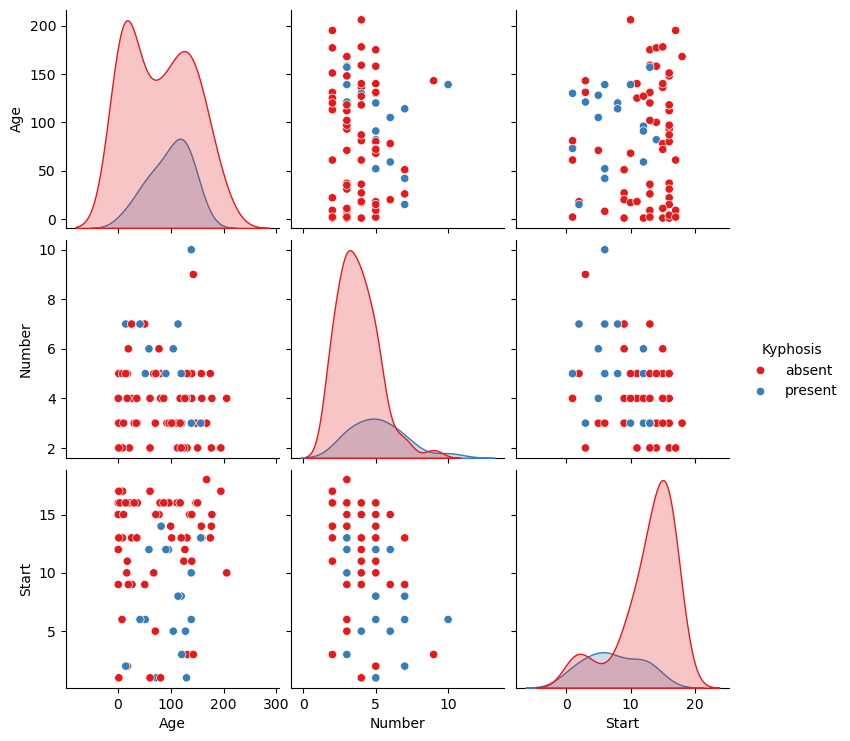

In [5]:
sb.pairplot(df, hue='Kyphosis', palette='Set1') #To see the varriety of the data distribution among themselves

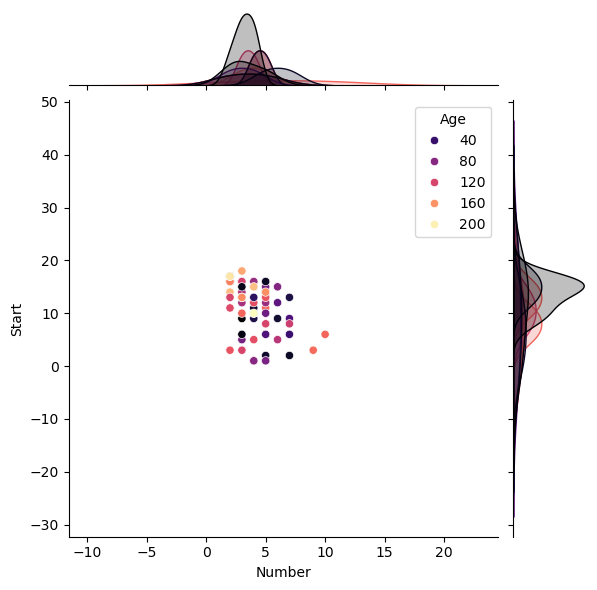

In [26]:
sb.jointplot(x='Number', y='Start', data=df, palette='magma', hue='Age')

**Let's train and Evaluate the Model**

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = df.drop('Kyphosis', axis=1) #Features of the dataset
y = df['Kyphosis'] #Target of the dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [13]:
from sklearn.tree import DecisionTreeClassifier #Importing the DTree module from sklearn

In [14]:
dtree = DecisionTreeClassifier()

In [15]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [16]:
pred = dtree.predict(X_test)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
print(classification_report(y_test, pred))
print("\n")
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

      absent       0.75      0.91      0.82        23
     present       0.60      0.30      0.40        10

    accuracy                           0.73        33
   macro avg       0.68      0.61      0.61        33
weighted avg       0.70      0.73      0.70        33



[[21  2]
 [ 7  3]]


In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rfc = RandomForestClassifier(n_estimators=300, random_state=101)

In [21]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=101)

In [22]:
pred_rfc = rfc.predict(X_test)

In [23]:
print(classification_report(y_test, pred_rfc))
print("\n")
print(confusion_matrix(y_test, pred_rfc))

              precision    recall  f1-score   support

      absent       0.74      1.00      0.85        23
     present       1.00      0.20      0.33        10

    accuracy                           0.76        33
   macro avg       0.87      0.60      0.59        33
weighted avg       0.82      0.76      0.69        33



[[23  0]
 [ 8  2]]


**After training the model using Random Forest, the acccuracy was increased to 3% i.e 76% that tooka decision from the many tree's and combined the decision**